# SMA Implementation

This notebook implements the slime mould algorithm as described in [Slime Mould Algorithm](https://doi.org/10.1016/j.future.2020.03.055). This implementation references [the author's MatLab code](
https://github.com/aliasgharheidaricom/Slime-Mould-Algorithm-A-New-Method-for-Stochastic-Optimization-) to resolve ambiguities.

This notebook uses the MIT license. Parts of the notebook transcribe (from MatLab to Python) work by Heidari under [the MIT license](https://github.com/aliasgharheidaricom/Slime-Mould-Algorithm-A-New-Method-for-Stochastic-Optimization-/blob/master/LICENSE). Heidari
is also an author of the base paper.


In [11]:
from typing import Literal as L, Callable
import numpy as np
import operator
import random
from numpy.random import default_rng

Set random seeds. Note that these seeds are also
used in later cells, for example by `default_rng`.

In [12]:
GLOBAL_SEED: int = 24601
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

Declare dimension of the problem: the size `D` of
each solution and the number `N` of solutions in the
population. Also declare related type aliases.

In [13]:
#: Number of solutions in the population.
N: int
#: Size of each solution; or dimension of the problem.
D: int

type Location = np.ndarray[tuple[L['D']],
                           np.dtype[np.float64]]
"""Type of a solution in R^D. Location of "one"
slime mould in a D-dimensional space.

Alias for D-vectors.
"""

type Population = np.ndarray[tuple[L['N'], L['D']],
                             np.dtype[np.float64]]
"""Type of the population in R^{N\\times D}. Each ith
item is a Location.
"""

#: Fitness of one solution. Semantic alias for Float64
type Fitness = np.float64

type Fitnesses = np.ndarray[tuple[L['N']],
                            np.dtype[np.float64]]
"""Type of the vector of fitnesses. Contains one item
for each of the N solutions.
Alias for D-vectors.
"""

"""A hyperparameter for the algorithm. The canonical code
uses this value.
"""

MAX_ITERATION: int


Define the population initialiser.
Parameters `UB` and `LB` limit the search space.

In [14]:
def initialise_population(N: int,
                          dim: int,
                          UB: Location,
                          LB: Location)\
        -> Population:
    """Given parameters, initialise a Population from
    parameters.
    """
    
    if np.any(UB<LB):
        raise ValueError(
            "For each index i, UB[i]"
            "must not be less than LB[i].")

    Xs = default_rng(GLOBAL_SEED).random((N, dim))
    print(Xs*(UB - LB) + LB)
    return Xs*(UB - LB) + LB

UB: Location
"""Upper bounds for items in a solution.
Xs[i][j] must not exceed UB[j].
"""

LB: Location
"""Lower bounds for items in a solution.
Xs[i][j] must not fall below LB[j].
""";

Initialise the fitness. Also define whether the
task is to maximise or minimise the objective function.

In [15]:
from dataclasses import dataclass

@dataclass
class SMAReport:
    #: Solutions in each generation.  0th is earliest.
    solutions: list[Population]
    #: Fitnesses in each generation. 0th is earliest.
    fitnesses: list[Fitnesses]
    #: Best solution ever.
    best_solution: Location
    #: Best fitness ever.
    best_fitness: Fitness
    #: Best solutions in each generation.  0th is earliest.
    gen_best_solutions: list[Location]
    #: Best fitnesses in each generation.  0th is earliest.
    gen_best_fitnesses: list[Fitness]

def sma(objective: Callable[[Location], Fitness],
        is_maximising: bool,
        max_iteration: int,
        pop_ub: Location,
        pop_lb: Location,
        ub: Location,
        lb: Location,
        N: int,
        D: int,
        Z: float,) -> SMAReport:
    

    historical_solutions: list[Population] = []
    historical_fitnesses: list[Fitnesses] = []
    gen_best_solutions: list[Location] = []
    gen_best_fitnesses: list[Fitness] = []

    Xs = initialise_population(N, D, pop_ub, pop_lb)

    #: The best solution.
    best_solution: Location
    #: Fitness of the best solution.
    best_fitness: Fitness

    # Initialise :var:`best_fitness` as the worst
    #   possible fitness. If algorithm is maximising,
    #   then best_fitness starts small. Otherwise,
    #   best_fitness starts large.
    if is_maximising:
        best_fitness = np.float64(np.finfo(np.float64).min)
    else:
        best_fitness = np.float64(np.finfo(np.float64).max)

    #: N-vector. S[i] is the fitness of the i^th solution.
    S: Fitnesses

    for t in range(max_iteration):
        # Bound each Xs[i][j] to between UB[j] and LB[j]

        for i in range(len(Xs)):
            # Xs[i,:] is the ith slice
            _ub_violation_mask = Xs[i,:] > ub

            Xs[i,:] = np.multiply(Xs[i,:], ~_ub_violation_mask) +\
                          np.multiply(ub, _ub_violation_mask)

            _lb_violation_mask = Xs[i,:] < lb
            Xs[i,:] = np.multiply(Xs[i,:], ~_lb_violation_mask) +\
                          np.multiply(lb, _lb_violation_mask)

        # Calculate fitnesses. S[i] is fitness(X[i,:])
        S = np.apply_along_axis(objective, 1, Xs)

        # Algorithm 1: Calculate the W by Eq. (2.5).
        # small_dict is an ordered list. It maps
        #   each index `smell_index: int` to the
        #   smell_index^{nd} best solution.
        # smell_indices: (dim,) of int
        # smells: (dim,) of floats

        # Implemented according to the canonical implementation.
        # The best is at index 0; the worst is at index N.
        # As such, sort according to :var:`IS_MAXIMISING`:
        smell_dict = np.array(sorted(list(enumerate(S)),  # type: ignore
                                     key=lambda x: x[1],
                                     reverse=True if is_maximising\
                                                  else False))

        weights = np.zeros(shape=(N, D))
        bF: np.float64 = smell_dict[0][1]
        wF: np.float64 = smell_dict[-1][1]

        # Partition smell_dict into two roughly-equal-sized
        #   matrices containing the better / worse halves.
        smell_dict_condition = smell_dict[0:int(N/2)]
        smell_dict_others = smell_dict[int(N/2):-1]

        # This variable is named S in the canonical implementation.
        # However, in the paper S means something different.
        # This is name is to avoid ambiguity.
        # `eps` is to avoid division by zero if bF=wF.
        #   The number is so infinitesimally small that we
        #   could probably ignore the probability that
        #   bF and wF differ by exactly eps.
        S_eps = best_fitness - wF + np.finfo(np.float64).eps # was bF in paper ... maybe try to be more aggressive?

        for j in range(0, D):
            for smell_index, smell_order in smell_dict_condition:
                weights[int(smell_index), j] = 1 + random.random()*np.log10((bF-smell_order)/(S_eps)+1)

            for smell_index, smell_order in smell_dict_others:
                weights[int(smell_index), j] = 1 - random.random()*np.log10((bF-smell_order)/(S_eps)+1)

        if is_maximising:
            is_better_than = operator.gt
        else:
            is_better_than = operator.lt

        if is_better_than(bF, best_fitness):
            # Recall that the 0th solution is best.
            best_fitness = smell_dict[0][1]
            best_solution = Xs[int(smell_dict[0][0])]
            
        # Replacing t in original with t+1 here. This is because
        # Matlab indices begin as 0.
        a = np.arctanh(1-(t+1)/max_iteration)  # Code says it's (2.4)
        b = 1 - (t+1)/max_iteration


        historical_solutions.append(Xs.copy())
        historical_fitnesses.append(S.copy())
        gen_best_solutions.append(Xs[int(smell_dict[0][0])].copy())
        gen_best_fitnesses.append(smell_dict[0][1].copy())

        for i in range(N):
            rand=random.random()
            # The code ... uses rand directly?
            if rand < Z: # Code says it's (2.7)
                Xs[i,:] = (pop_ub-pop_lb)*random.random() + pop_lb
            else:
                # AllFitness in code is S here
                
                p = np.tanh(np.abs(S[i] - best_fitness))
                vb = np.random.uniform(low=-a, high=a, size=(D,)) # Code says it's 2.3
                vc = np.random.uniform(low=-b, high=b, size=(D,))

            for j in range(D):
                r = random.random()
                A = random.randint(0, N-1)
                B = random.randint(0, N-1)
                
                if r < p:
                    Xs[i, j] = best_solution[j] + vb[j] * (weights[i, j]*Xs[A,j]-Xs[B,j])
                else:
                    Xs[i, j] = vc[j] * Xs[i,j]


    result: SMAReport = SMAReport(
        solutions=historical_solutions,
        fitnesses=historical_fitnesses,
        best_solution=best_solution,
        best_fitness=best_fitness,
        gen_best_solutions=gen_best_solutions,
        gen_best_fitnesses=gen_best_fitnesses,
    )
    return result

    

Parameterise and run the algorithm.

In [16]:
from ograph import ofunc, oplot

In [17]:
N = 200
D = 2
POP_UB = np.ones(shape=(D,)) * -1
POP_LB = np.ones(shape=(D,)) * -4
UB = np.ones(shape=(D,)) * 7
LB = np.ones(shape=(D,)) * -7
IS_MAXIMISING: bool = True
Z = 0.03
MAX_ITERATION = 200


#: The objective function
OBJECTIVE: Callable[[Location], Fitness] =\
    lambda x: ofunc.himmelblau(x[0],
                               x[1]) * -1\
    if IS_MAXIMISING else 1  # type: ignore


report: SMAReport = sma(objective = OBJECTIVE,
                        is_maximising = IS_MAXIMISING,
                        max_iteration = MAX_ITERATION,
                        pop_ub=POP_UB,
                        pop_lb=POP_LB,
                        ub=UB,
                        lb=LB,
                        N=N,
                        D=D,
                        Z=Z)

[[-2.47592429 -1.81997011]
 [-2.95540877 -3.33771139]
 [-2.74391284 -1.82419344]
 [-3.70899605 -1.68464243]
 [-3.12115934 -1.37014237]
 [-2.53291771 -3.64338561]
 [-1.72119328 -1.28885633]
 [-2.33623507 -1.08980774]
 [-3.26921986 -2.55601543]
 [-3.12279309 -2.57700669]
 [-3.38698749 -1.15188707]
 [-2.05444234 -1.46576723]
 [-1.60774563 -3.08985395]
 [-1.35949565 -1.44753345]
 [-2.03237569 -2.18611263]
 [-1.91113253 -3.40816876]
 [-3.45566262 -3.36016751]
 [-3.61281961 -2.52430802]
 [-1.02348297 -2.21315978]
 [-1.92142152 -2.66819629]
 [-2.39064646 -2.91871284]
 [-1.23466717 -2.51284576]
 [-2.55051423 -3.798853  ]
 [-3.95026681 -3.83633743]
 [-3.96621018 -1.98419591]
 [-3.50945244 -1.27658987]
 [-3.22636507 -2.85088508]
 [-2.44282669 -2.4260564 ]
 [-1.53628828 -2.69364699]
 [-2.36810088 -1.00410217]
 [-3.11530769 -2.05087961]
 [-2.05258559 -3.36806285]
 [-3.53886252 -3.9694065 ]
 [-1.3621931  -1.16921042]
 [-1.696319   -2.74432217]
 [-3.81658648 -2.77322841]
 [-3.93657671 -1.2421323 ]
 

## Visualise

In [18]:
print(f"Best solution is {report.best_solution}, with fitness {report.best_fitness}")

Best solution is [-3.31078708 -3.3121009 ], with fitness -0.032185163502593615


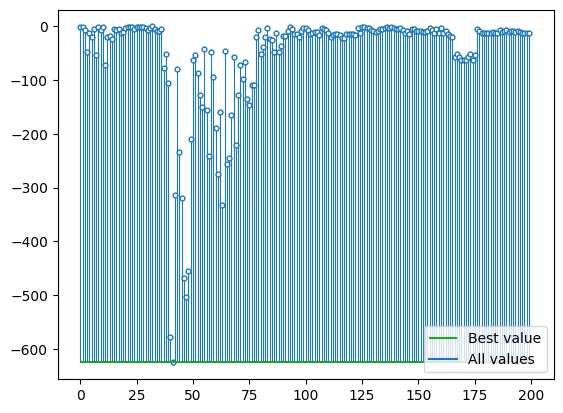

In [ ]:
from ograph.swarm import plot_fitnesses

plot_fitnesses(report.gen_best_fitnesses,
               best_selector=max)

In [20]:
plot_bests(report.solutions, report.gen_best_fitnesses)

NameError: name 'plot_bests' is not defined

### Visualise Particles



In [ ]:
from ograph.swarm import plot_positions, animate_positions

In [ ]:
plot_positions(report.solutions,
               objective=lambda x, y: OBJECTIVE((x, y)))

Because the ipython notebook might not correctly render gifs, the animation will be saved to the working directory.

In [ ]:
animate_positions(report.solutions,
                  objective=lambda x, y: OBJECTIVE((x, y)))